### Plot Functions

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import json
import scipy
import math

In [2]:
PATH_hh = "E://P5_5_SFT_dynamics//results_visualize//exp_results_hh"
PATH_fb = "E://P5_5_SFT_dynamics//results_visualize//exp_results_ultrafb"

RESPONSE_LIST = ['chosen', 'chosen_initial', 'chosen_selfr', 'chosen_gptsemantic', 'chosen_gptformat',
                 'rejected', 'reject_gptsemantic', 'reject_gptformat',
                 'irr_train', 'irr_test', 'irr_hum',
                 'random_permute', 'random_nonhum',
                 'argmax'
                 ]

In [3]:
def read_json_old_exps(file_path, train_test='train'):
    results = {'chosen': [], 'chosen_initial': [], 'chosen_selfr': [], 'chosen_gptsemantic': [], 'chosen_gptformat': [],
               'rejected': [], 'reject_gptsemantic': [], 'reject_gptformat': [],
               'irr_train': [], 'irr_test': [], 'irr_hum': [],
               'random_permute': [], 'random_nonhum': [],
               'argmax': []}

    # 处理 NaN / Inf
    def parse_constant(x):
        if x == 'NaN':
            return math.nan
        if x == 'Infinity':
            return math.inf
        if x == '-Infinity':
            return -math.inf
        return x

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            dict_line = json.loads(line, parse_constant=parse_constant)

            for key in RESPONSE_LIST:
                if key == 'argmax':
                    true_key = 'argmax_prob_logits'
                else:
                    true_key = f'logps_eval_prob_{train_test}/{key}'

                results[key].append(dict_line.get(true_key, 0.01))

    return results


def smooth_path(origin_path, alpha=0.9):
    origin_path_ = np.array(origin_path)
    smoothed_path = np.zeros_like(origin_path_)
    smoothed_path[0] = origin_path_[0]
    for i in range(1, origin_path_.shape[0]):
        smoothed_path[i] = smoothed_path[i-1]*alpha + origin_path_[i]*(1-alpha)
    return smoothed_path

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_dpo_graph(PATH, MODEL_SEQ, LEGENDS, COLORS, OBS_NUM, SMTH, y_margin_ratio=0.08):
    fig, ax = plt.subplots(1, 4, figsize=(20, 4))

    # 收集每个子图所有y数据，用于自动设定y轴范围
    ys_all = [[], [], [], []]  # 对应 ax[0], ax[1], ax[2], ax[3]

    for j in range(3):
        # 读取
        file_path = os.path.join(PATH, MODEL_SEQ[j][0], 'prob_train_metrics.json')
        sft_results = read_json_old_exps(file_path)
        file_path = os.path.join(PATH, MODEL_SEQ[j][1], 'prob_train_metrics.json')
        dpo_results = read_json_old_exps(file_path)

        down_smp = 2
        obs_smp = 40

        # x 轴
        x_axis = np.arange(0, len(sft_results['chosen'][:obs_smp:down_smp] + dpo_results['chosen'])) * 100 / 500

        # 子图0
        y0 = sft_results['chosen'][:obs_smp:down_smp] + list(smooth_path(dpo_results['chosen'], SMTH))
        ax[0].plot(x_axis, y0, label=LEGENDS[j], color=COLORS[j])
        ys_all[0].extend(y0)

        # 子图1
        y1 = sft_results['rejected'][:obs_smp:down_smp] + list(smooth_path(dpo_results['rejected'], SMTH))
        ax[1].plot(x_axis, y1, label=LEGENDS[j], color=COLORS[j])
        ys_all[1].extend(y1)

        # 子图2：多条线
        y2_a = sft_results['chosen_gptsemantic'][:obs_smp:down_smp] + list(smooth_path(dpo_results['chosen_gptsemantic'], SMTH))
        y2_b = sft_results['chosen_gptformat'][:obs_smp:down_smp] + list(smooth_path(dpo_results['chosen_gptformat'], SMTH))
        y2_c = sft_results['reject_gptsemantic'][:obs_smp:down_smp] + list(smooth_path(dpo_results['reject_gptsemantic'], SMTH))
        y2_d = sft_results['reject_gptformat'][:obs_smp:down_smp] + list(smooth_path(dpo_results['reject_gptformat'], SMTH))
        y2_e = sft_results['random_permute'][:obs_smp:down_smp] + list(smooth_path(dpo_results['random_permute'], SMTH))
        y2_f = sft_results['random_nonhum'][:obs_smp:down_smp] + list(smooth_path(dpo_results['random_nonhum'], SMTH))

        ax[2].plot(x_axis, y2_a, label=LEGENDS[j], color=COLORS[j])
        ax[2].plot(x_axis, y2_b, label=LEGENDS[j], color=COLORS[j], linestyle='dotted')
        ax[2].plot(x_axis, y2_c, label=LEGENDS[j], color=COLORS[j], linestyle='dashed')
        ax[2].plot(x_axis, y2_d, label=LEGENDS[j], color=COLORS[j], linestyle='dashdot')
        ax[2].plot(x_axis, y2_e, label=LEGENDS[j], color=COLORS[j], alpha=0.5)
        ax[2].plot(x_axis, y2_f, label=LEGENDS[j], color=COLORS[j], alpha=0.5, linestyle='dotted')

        ys_all[2].extend(y2_a + y2_b + y2_c + y2_d + y2_e + y2_f)

        # 子图3
        y3 = sft_results['argmax'][:obs_smp:down_smp] + list(smooth_path(dpo_results['argmax'], SMTH))
        ax[3].plot(x_axis, y3, label=LEGENDS[j], color=COLORS[j])
        ys_all[3].extend(y3)

    # 公共设置
    ax[0].legend(fontsize=16)
    for i in range(4):
        ax[i].grid(True)

    ax[0].set_title(r'Chosen $y_u^+$', fontsize=16)
    ax[0].set_ylabel(r'Log probability', fontsize=16)
    ax[0].set_xlabel(r'Number of epochs', fontsize=16)

    ax[1].set_title(r'Rejected $y_u^-$', fontsize=16)
    ax[1].set_xlabel(r'Number of epochs', fontsize=16)

    ax[2].set_title(r'Other responses', fontsize=16)
    ax[2].set_xlabel(r'Number of epochs', fontsize=16)

    ax[3].set_title(r'Argmax response', fontsize=16)
    ax[3].set_xlabel(r'Number of epochs', fontsize=16)

    # === 按每个子图自身的最小最大值设定 y 轴 + 边距；再画竖线和注释 ===
    for i in range(4):
        if len(ys_all[i]) == 0:
            continue
        y_min = float(np.min(ys_all[i]))
        y_max = float(np.max(ys_all[i]))
        if y_min == y_max:
            # 退化情形，给一个小范围
            pad = max(1.0, abs(y_min) * 0.1)
            ax[i].set_ylim(y_min - pad, y_max + pad)
        else:
            margin = (y_max - y_min) * y_margin_ratio
            ax[i].set_ylim(y_min - margin, y_max + margin)

        # 竖线 x=4，按当前y范围画
        cur_ymin, cur_ymax = ax[i].get_ylim()
        ax[i].plot([4, 4], [cur_ymin, cur_ymax], color='black', linestyle='dashdot')

    # 调整注释：用比例位置，避免越界
    y1min, y1max = ax[1].get_ylim()
    ax[1].annotate(r'$y_u^-$ is the' + '\n peak now',
                   xy=(3.9, y1max - 0.05*(y1max - y1min)),
                   xytext=(2.0, y1min + 0.25*(y1max - y1min)),
                   arrowprops=dict(arrowstyle="simple", color='darkred'),
                   ha='center', color='darkred', fontsize=16)

    y2min, y2max = ax[2].get_ylim()
    ax[2].annotate('All rephrases',
                   xy=(4.0, y2min + 0.70*(y2max - y2min)),
                   xytext=(2.0, y2min + 0.50*(y2max - y2min)),
                   arrowprops=dict(arrowstyle="simple", color='darkred'),
                   ha='center', color='darkred', fontsize=16)

    ax[2].annotate('Non-human\n sequence',
                   xy=(4.0, y2min + 0.30*(y2max - y2min)),
                   xytext=(2.0, y2min + 0.15*(y2max - y2min)),
                   arrowprops=dict(arrowstyle="simple", color='darkred'),
                   ha='center', color='darkred', fontsize=16)

    y3min, y3max = ax[3].get_ylim()
    ax[3].annotate('Drop at the\n start of DPO',
                   xy=(5.0, y3min + 0.30*(y3max - y3min)),
                   xytext=(7.0, y3min + 0.15*(y3max - y3min)),
                   arrowprops=dict(arrowstyle="simple", color='darkred'),
                   ha='center', color='darkred', fontsize=16)

    plt.tight_layout()
    plt.show()


In [5]:
def plot_dpo_log_details(PATH,MODEL):
    # model = "dpo_pythia410m"# 'dpo_pythia28'#
    file_path = os.path.join(PATH,MODEL, 'prob_train_metrics.json')
    results = read_json_old_exps(file_path)
    # results_argmax = read_json_old_exps(os.path.join(PATH, 'dpo_pythia410m_sft0_observeargmax2/prob_train_metrics.json'))


    x_axis = np.arange(0,len(results['chosen']))*100/5000
    OBS_NUM = -1
    fig, ax = plt.subplots(1,5,figsize=(20,4))

    A = 3

    ax[A].plot(x_axis[:OBS_NUM], results['chosen'][:OBS_NUM], label=r'$y_u^+$', color='blue')
    ax[A].plot(x_axis[:OBS_NUM], results['rejected'][:OBS_NUM], label=r'$y_u^-$',color='orange')
    ax[A].grid(True)
    ax[A].legend(fontsize=18, loc='lower left')
    ax[A].set_title('Chosen v.s. rejected',fontsize=16)
    ax[A].set_xlabel('Number of epochs',fontsize=16)

    B = 0
    ax[B].plot(x_axis[:OBS_NUM], results['chosen'][:OBS_NUM], label=r'$y_u^+$', color='blue', linewidth=3)
    ax[B].plot(x_axis[:OBS_NUM], results['chosen_gptsemantic'][:OBS_NUM], label=r'$y_\text{gpts}^+$',color='navy')
    ax[B].plot(x_axis[:OBS_NUM], results['chosen_gptformat'][:OBS_NUM], label=r'$y_\text{gptf}^+$',color='skyblue')
    ax[B].grid(True)
    ax[B].legend(fontsize=18, loc='lower left')
    ax[B].set_title('Chosen v.s. its rephrases',fontsize=16)
    ax[B].set_xlabel('Number of epochs',fontsize=16)
    ax[B].set_ylabel('Averge log-probability',fontsize=16)

    C = 1
    ax[C].plot(x_axis[:OBS_NUM], results['rejected'][:OBS_NUM], label=r'$y_u^-$', color='orange', linewidth=3)
    ax[C].plot(x_axis[:OBS_NUM], results['reject_gptsemantic'][:OBS_NUM], label=r'$y_\text{gpts}^-$',color='darkred',alpha=0.5)
    ax[C].plot(x_axis[:OBS_NUM], results['reject_gptformat'][:OBS_NUM], label=r'$y_\text{gptf}^-$',color='red',alpha=0.5)
    ax[C].grid(True)
    ax[C].legend(fontsize=18, loc='lower left')
    ax[C].set_title('Rejected v.s. its rephrases',fontsize=16)
    ax[C].set_xlabel('Number of epochs',fontsize=16)

    D = 2
    ax[D].plot(x_axis[:OBS_NUM], smooth_path(results['chosen_gptsemantic'][:OBS_NUM], 0.9), label=r'$y_\text{gpts}^+$',color='blue')
    ax[D].plot(x_axis[:OBS_NUM], smooth_path(results['reject_gptsemantic'][:OBS_NUM], 0.9), label=r'$y_\text{gpts}^-$',color='orange')
    ax[D].plot(x_axis[:OBS_NUM], smooth_path(results['chosen_gptformat'][:OBS_NUM], 0.9), label=r'$y_\text{gptf}^+$',color='blue',linestyle='dashed')
    ax[D].plot(x_axis[:OBS_NUM], smooth_path(results['reject_gptformat'][:OBS_NUM], 0.9), label=r'$y_\text{gptf}^-$',color='orange',linestyle='dashed')
    ax[D].grid(True)
    ax[D].legend(fontsize=18, loc='lower left')#,ncol=2)
    ax[D].set_title('Rejected v.s. its rephrases',fontsize=16)
    ax[D].set_xlabel('Number of epochs',fontsize=16)

    OBS_NUM = 400
    E = 4
    ax[E].plot(x_axis[:OBS_NUM], results['argmax'][:OBS_NUM], label='Argmax', color='black', linewidth=3)
    ax[E].plot(x_axis[:OBS_NUM], results['chosen'][:OBS_NUM], color='blue')
    ax[E].plot(x_axis[:OBS_NUM], results['rejected'][:OBS_NUM],color='orange')
    ax[E].plot(x_axis[:OBS_NUM], smooth_path(results['chosen_gptsemantic'][:OBS_NUM], 0.9))
    ax[E].plot(x_axis[:OBS_NUM], smooth_path(results['reject_gptsemantic'][:OBS_NUM], 0.9))
    ax[E].plot(x_axis[:OBS_NUM], smooth_path(results['chosen_gptformat'][:OBS_NUM], 0.9))
    ax[E].plot(x_axis[:OBS_NUM], smooth_path(results['reject_gptformat'][:OBS_NUM], 0.9))
    ax[E].plot(x_axis[:OBS_NUM], smooth_path(results['chosen_initial'][:OBS_NUM], 0.9))
    ax[E].plot(x_axis[:OBS_NUM], smooth_path(results['irr_train'][:OBS_NUM], 0.9))
    ax[E].plot(x_axis[:OBS_NUM], smooth_path(results['irr_test'][:OBS_NUM], 0.9))
    ax[E].plot(x_axis[:OBS_NUM], smooth_path(results['irr_hum'][:OBS_NUM], 0.9))


    ax[E].annotate('All other responses', xy=(4,-200), xytext=(5.5, -120), arrowprops=dict(arrowstyle="simple",color='blue',),
                          horizontalalignment='center',color='blue',fontsize=16)

    ax[4].grid(True)
    ax[4].legend(fontsize=18, loc='lower left')#,ncol=2)
    ax[4].set_title('Where the probability mass gone?',fontsize=16)
    ax[4].set_xlabel('Number of epochs',fontsize=16)

    plt.tight_layout()
    # save_name = os.path.join('figures','dpo_all.pdf')
    # plt.savefig(save_name)
    plt.show()

In [6]:
def read_json_new_metrics(file_path, train_test='train'):
    """
    自动识别以下格式：
      - JSONL（每行一个 JSON）
      - JSON 数组 [ {...}, {...} ]
      - 多个 JSON 拼接 {...}{...}{...}
    """
    PREFIXES = [
        'softmax_','label_eq_argmax_ratio_'
    ]
    results = {f"{p.strip('_')}_{k}": [] for p in PREFIXES for k in RESPONSE_LIST}

    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read().strip()

    # === 情况 1：JSON 数组 ===
    if content.startswith('['):
        data_list = json.loads(content)
    # === 情况 2：JSONL ===
    elif '\n' in content and content.strip().startswith('{') and '}\n{' in content:
        data_list = [json.loads(line) for line in content.split('\n') if line.strip()]
    # === 情况 3：多个 JSON 拼接 {...}{...} ===
    elif '}{' in content:
        data_list = []
        parts = content.replace('}{', '}\n{').split('\n')
        for p in parts:
            if p.strip():
                data_list.append(json.loads(p))
    # === 情况 4：单个 JSON ===
    else:
        data_list = [json.loads(content)]

    # === 提取字段 ===
    for dict_line in data_list:
        for key in RESPONSE_LIST:
            for p in PREFIXES:
                full_key = f"{p}mean_eval_prob_{train_test}/{key}"
                dict_key = f"{p.strip('_')}_{key}"
                # print(full_key)
                # print(dict_key)
                if full_key in dict_line:
                    results[dict_key].append(dict_line[full_key])
                else:
                    results[dict_key].append(np.nan)
    return results


In [9]:
def plot_softmax_dpo(PATH,MODEL):
    file_path = os.path.join(PATH, MODEL, "prob_train_metrics.json")
    results = read_json_new_metrics(file_path)
    x_axis = np.arange(0, len(results['softmax_chosen'])) * 100 / 5000
    OBS_NUM = -1

    fig, ax = plt.subplots(2, 3, figsize=(20, 12))
    plt.subplots_adjust(hspace=0.4)

    # ===================== 第一行：Softmax =====================
    ax[0,0].plot(x_axis, results['softmax_chosen'], label=r'$y_u^+$', color='blue', linewidth=3)
    ax[0,0].plot(x_axis, results['softmax_chosen_gptsemantic'], label=r'$y_\text{gpts}^+$', color='navy')
    ax[0,0].plot(x_axis, results['softmax_chosen_gptformat'], label=r'$y_\text{gptf}^+$', color='skyblue')
    ax[0,0].set_title('[Softmax] Chosen v.s. rephrases'); ax[0,0].grid(True); ax[0,0].legend(fontsize=9)

    ax[0,1].plot(x_axis, results['softmax_rejected'], label=r'$y_u^-$', color='orange', linewidth=3)
    ax[0,1].plot(x_axis, results['softmax_reject_gptsemantic'], label=r'$y_\text{gpts}^-$', color='darkred', alpha=0.7)
    ax[0,1].plot(x_axis, results['softmax_reject_gptformat'], label=r'$y_\text{gptf}^-$', color='red', alpha=0.7)
    ax[0,1].set_title('[Softmax] Rejected v.s. rephrases'); ax[0,1].grid(True); ax[0,1].legend(fontsize=9)

    ax[0,2].plot(x_axis, results['softmax_chosen_gptsemantic'], label=r'$y_\text{gpts}^+$', color='blue')
    ax[0,2].plot(x_axis, results['softmax_reject_gptsemantic'], label=r'$y_\text{gpts}^-$', color='orange')
    ax[0,2].plot(x_axis, results['softmax_chosen_gptformat'], label=r'$y_\text{gptf}^+$', color='blue', linestyle='dashed')
    ax[0,2].plot(x_axis, results['softmax_reject_gptformat'], label=r'$y_\text{gptf}^-$', color='orange', linestyle='dashed')
    ax[0,2].set_title('[Softmax] Rephrased Comparison'); ax[0,2].grid(True); ax[0,2].legend(fontsize=9)

    ax[1,0].plot(x_axis, results['softmax_chosen'], label=r'$y_u^+$', color='blue')
    ax[1,0].plot(x_axis, results['softmax_rejected'], label=r'$y_u^-$', color='orange')
    ax[1,0].set_title('[Softmax] Chosen v.s. Rejected'); ax[1,0].grid(True); ax[1,0].legend(fontsize=9)

    ax[1,1].plot(x_axis, results['softmax_chosen'], color='blue')
    ax[1,1].plot(x_axis, results['softmax_rejected'], color='orange')
    ax[1,1].plot(x_axis, results['softmax_irr_train'], label='irr_train', color='purple')
    ax[1,1].plot(x_axis, results['softmax_irr_test'], label='irr_test', color='green')
    ax[1,1].plot(x_axis, results['softmax_chosen_gptsemantic'], label=r'$y_\text{gpts}^+$', color='blue')
    ax[1,1].plot(x_axis, results['softmax_reject_gptsemantic'], label=r'$y_\text{gpts}^-$', color='orange')
    ax[1,1].plot(x_axis, results['softmax_chosen_gptformat'], label=r'$y_\text{gptf}^+$', color='blue', linestyle='dashed')
    ax[1,1].plot(x_axis, results['softmax_reject_gptformat'], label=r'$y_\text{gptf}^-$', color='orange', linestyle='dashed')
    # ax[0,4].plot(x_axis, results['softmax_argmax_chosen'], label='argmax', color='black')
    ax[1,1].set_title('[Softmax] All other responses'); ax[1,1].grid(True); ax[1,1].legend(fontsize=9)



    ax[1,2].plot(x_axis, results['label_eq_argmax_ratio_chosen'], label='chosen', color='blue')
    ax[1,2].plot(x_axis, results['label_eq_argmax_ratio_rejected'], label='rejected', color='orange')
    ax[1,2].set_title('[Label == Argmax Ratio]'); ax[1,2].grid(True); ax[1,2].legend(fontsize=9)

    plt.tight_layout()
    plt.show()
PATH = 'D:\Learning\\NUS\CFAIR\LearningDynamics\Code\src\exp_results'
MODEL_SEQ = [("base_sft_qwen18_ep8", "base_dpo_qwen_ep6_repaired"),
                 ("extend_sft_qwen18_ep4", "extend_dpo_qwen18_ep6_repaired"),
                 ("base_sft_qwen18_ep8", "sparse_dpo_qwen18_ep6_repaired")
                 ]
LEGENDS = ['baseline', 'extend', 'sparse-dpo']
COLORS = ['blue', 'orange', 'red']
OBS_NUM = -1
SMTH = 0.5

### Sparese-Dpo(Abandoned)

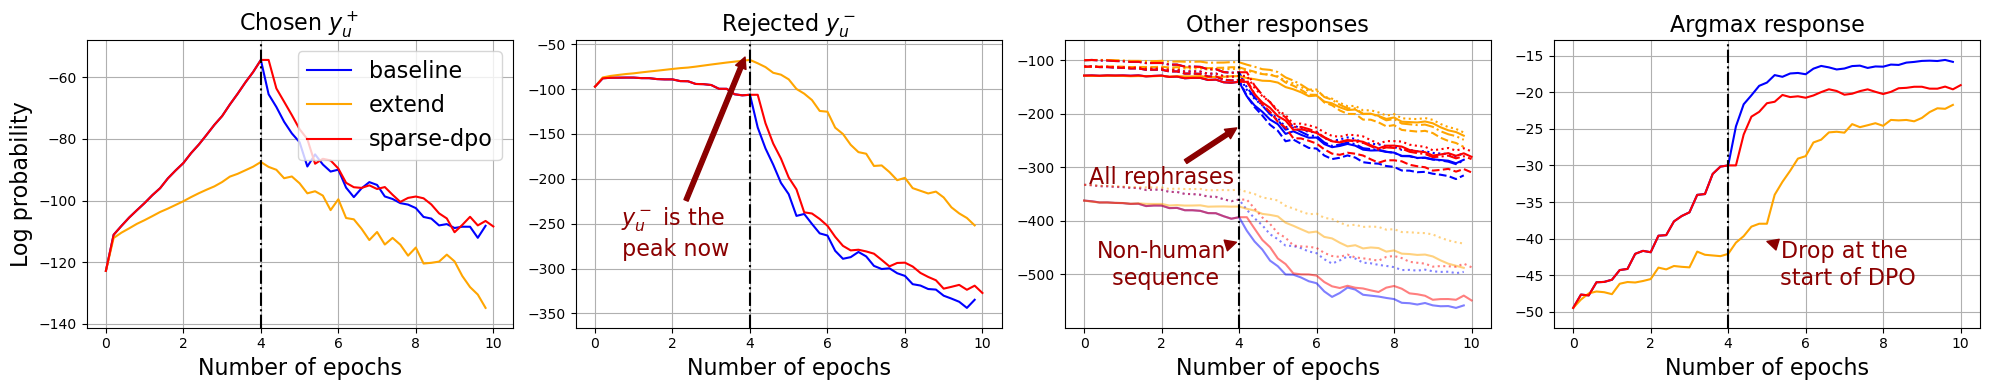

In [8]:
plot_dpo_graph(PATH, MODEL_SEQ, LEGENDS, COLORS, OBS_NUM, SMTH)

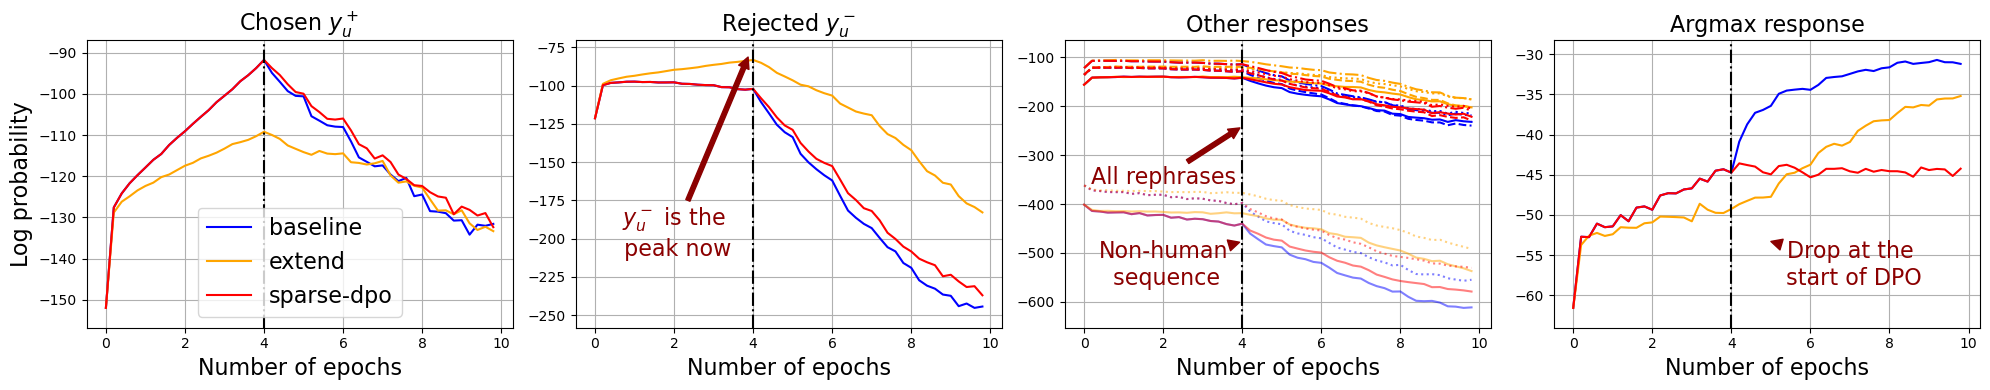

In [9]:
MODEL_SEQ = [("base_hh_sft_pythia410m_ep8", "base_dpo_hh_pythia410m_ep6"),
             ("extend_hh_sft_pythia410m_ep8", "extend_dpo_hh_pythia410m_ep6"),
             ("base_hh_sft_pythia410m_ep8","sparse_dpo_hh_pythia410m_ep6")
             ]
plot_dpo_graph(PATH, MODEL_SEQ, LEGENDS, COLORS, OBS_NUM, SMTH)

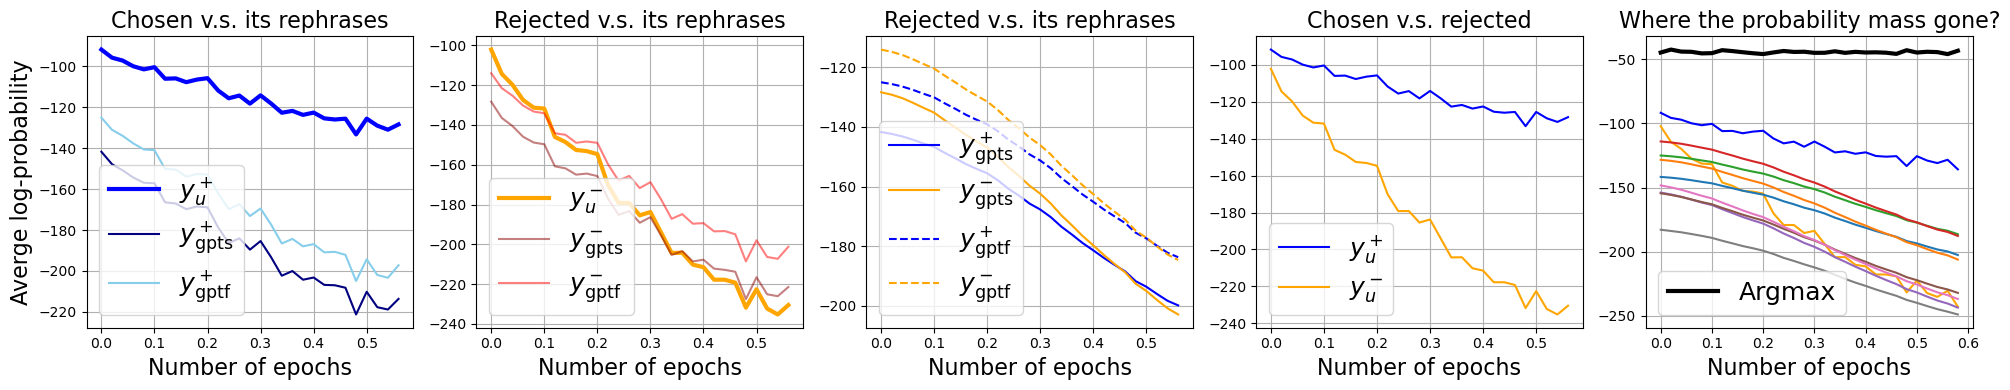

In [10]:
MODEL = "sparse_dpo_hh_pythia410m_ep6"
plot_dpo_log_details(PATH,MODEL)

### Masked-Dpo Qwen

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Learning\\NUS\\CFAIR\\LearningDynamics\\Code\\src\\exp_results\\masked_dpo_ultrafb_qwen18_ep6\\prob_train_metrics.json'

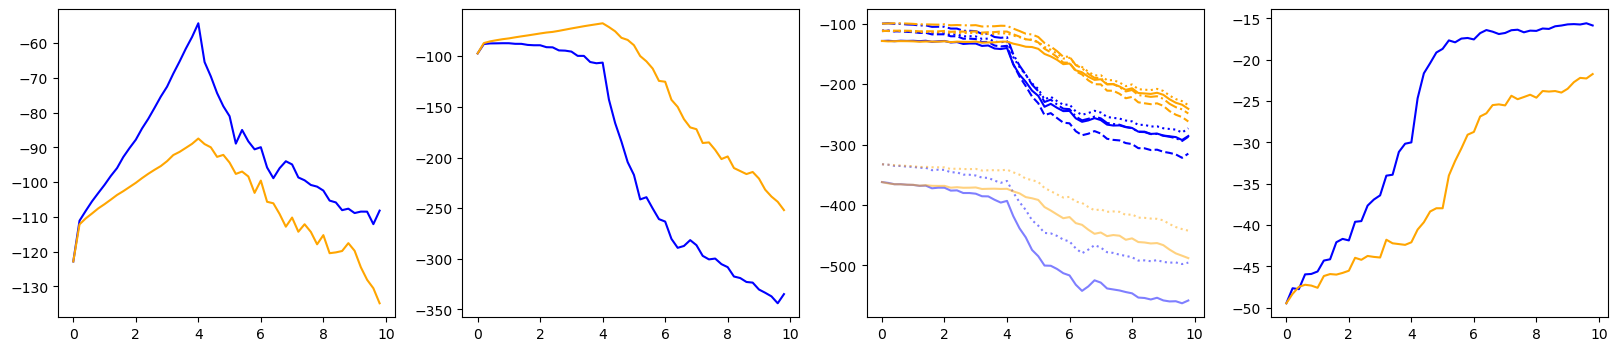

In [29]:
#   Figures
MODEL_SEQ = [("base_sft_qwen18_ep8", "base_dpo_qwen_ep6_repaired"),
             ("extend_sft_qwen18_ep4", "extend_dpo_qwen18_ep6_repaired"),
             ("base_sft_qwen18_ep8", "masked_dpo_ultrafb_qwen18_ep6")
             ]
LEGENDS = ['baseline', 'extend', 'masked_dpo']
plot_dpo_graph(PATH, MODEL_SEQ, LEGENDS, COLORS, OBS_NUM, SMTH)

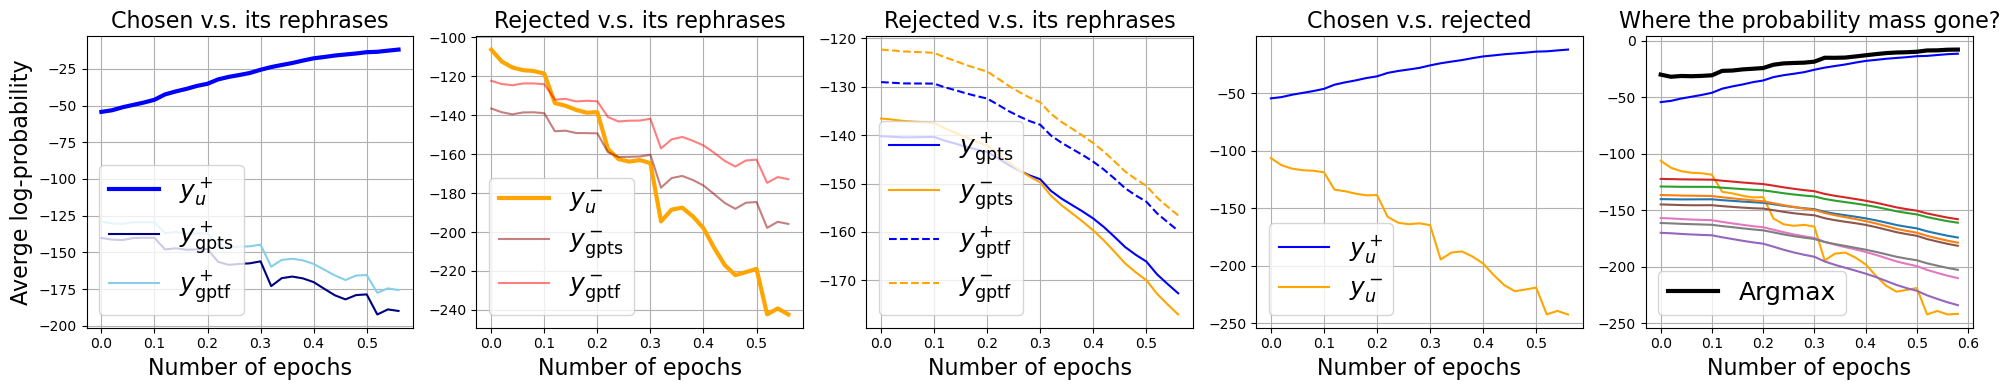

In [13]:
MODEL = "masked_dpo_hh_qwen18_ep6"
plot_dpo_log_details(PATH,MODEL)

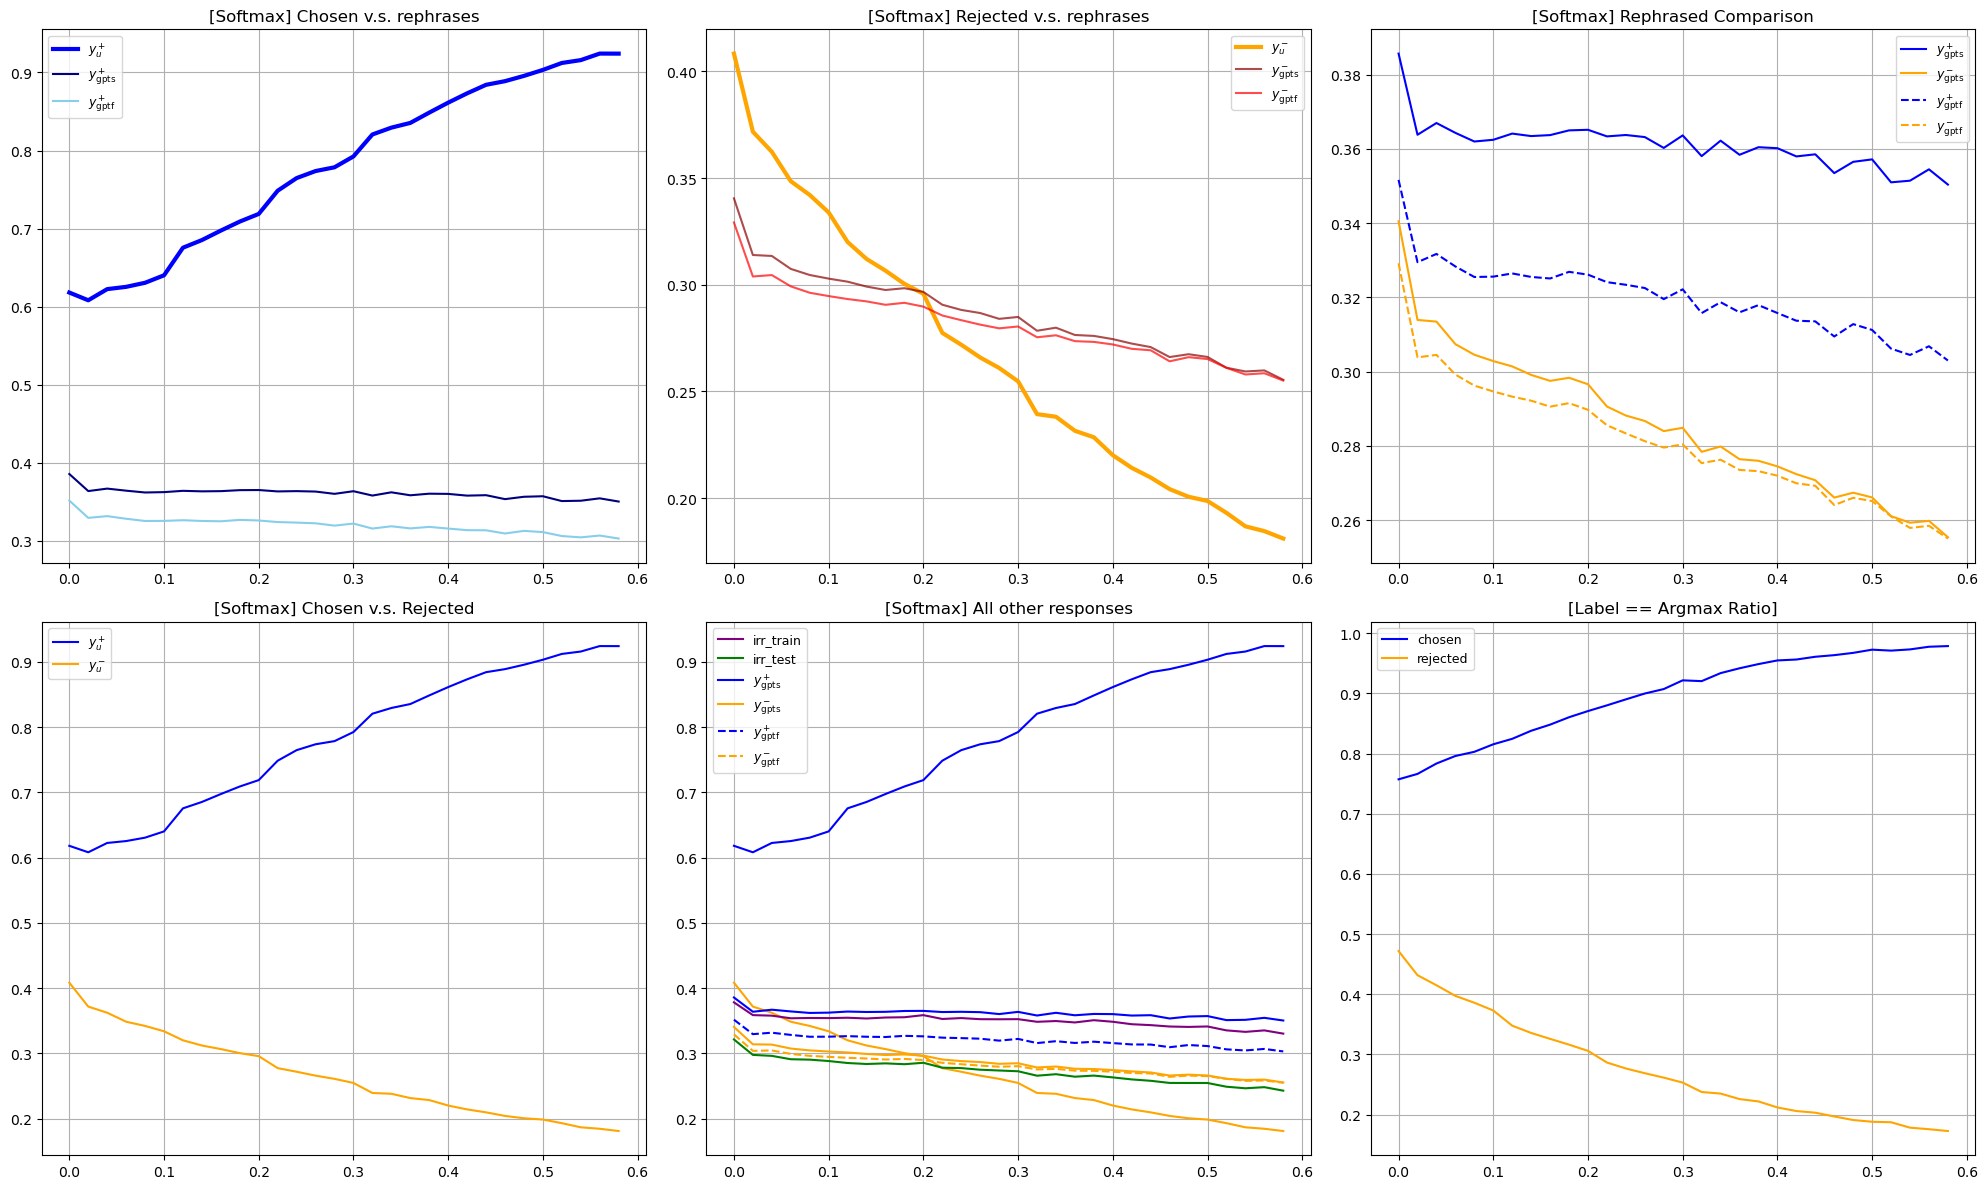

In [14]:
MODEL="masked_dpo_hh_qwen18_ep6"
plot_softmax_dpo(PATH, MODEL)

### Masked-Dpo pythia410m

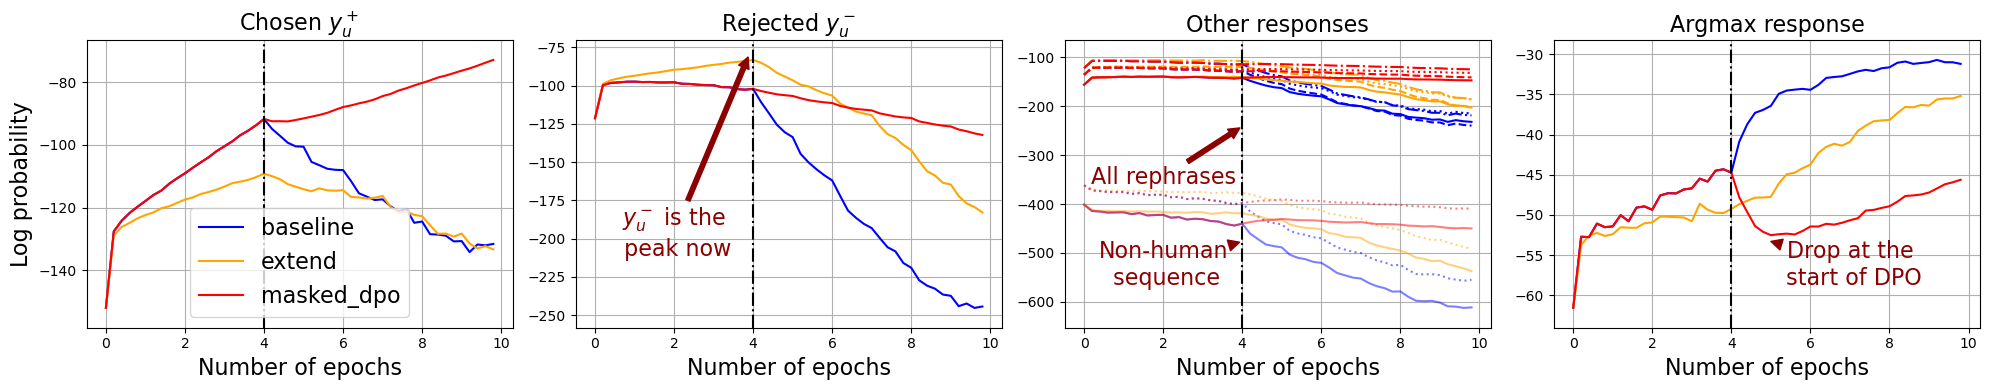

In [15]:
#   Figures
MODEL_SEQ = [("base_hh_sft_pythia410m_ep8", "base_dpo_hh_pythia410m_ep6"),
             ("extend_hh_sft_pythia410m_ep8", "extend_dpo_hh_pythia410m_ep6"),
             ("base_hh_sft_pythia410m_ep8", "masked_dpo_hh_pythia410m_ep6")
             ]
LEGENDS = ['baseline', 'extend', 'masked_dpo']
plot_dpo_graph(PATH, MODEL_SEQ, LEGENDS, COLORS, OBS_NUM, SMTH)

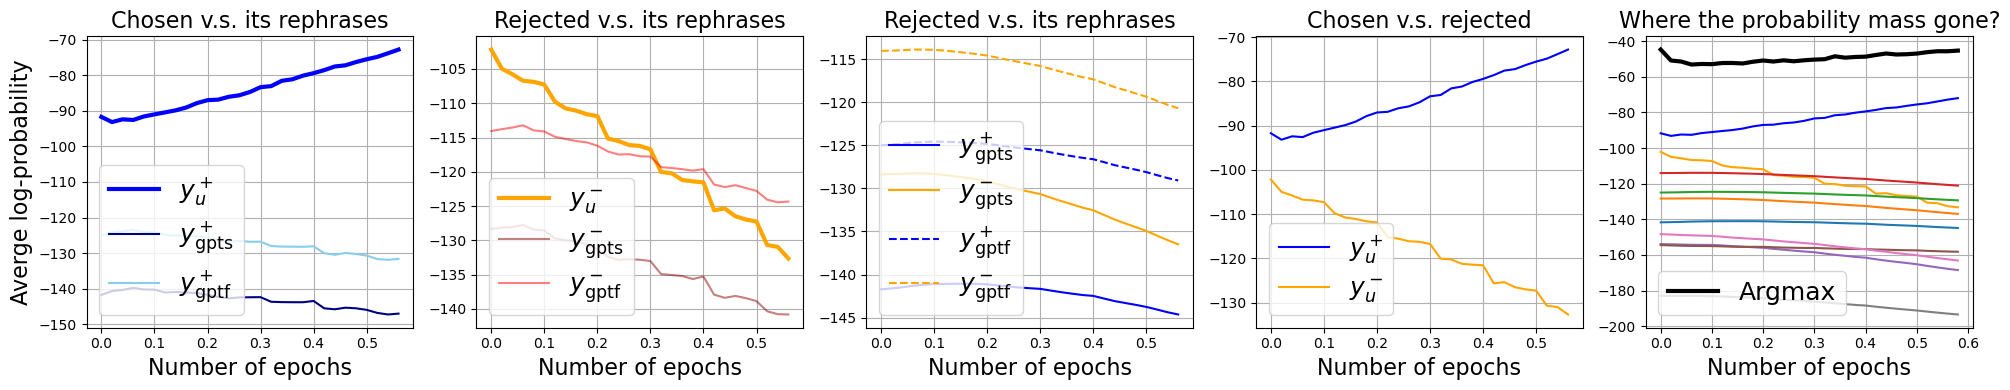

In [16]:
MODEL = "masked_dpo_hh_pythia410m_ep6"
plot_dpo_log_details(PATH,MODEL)

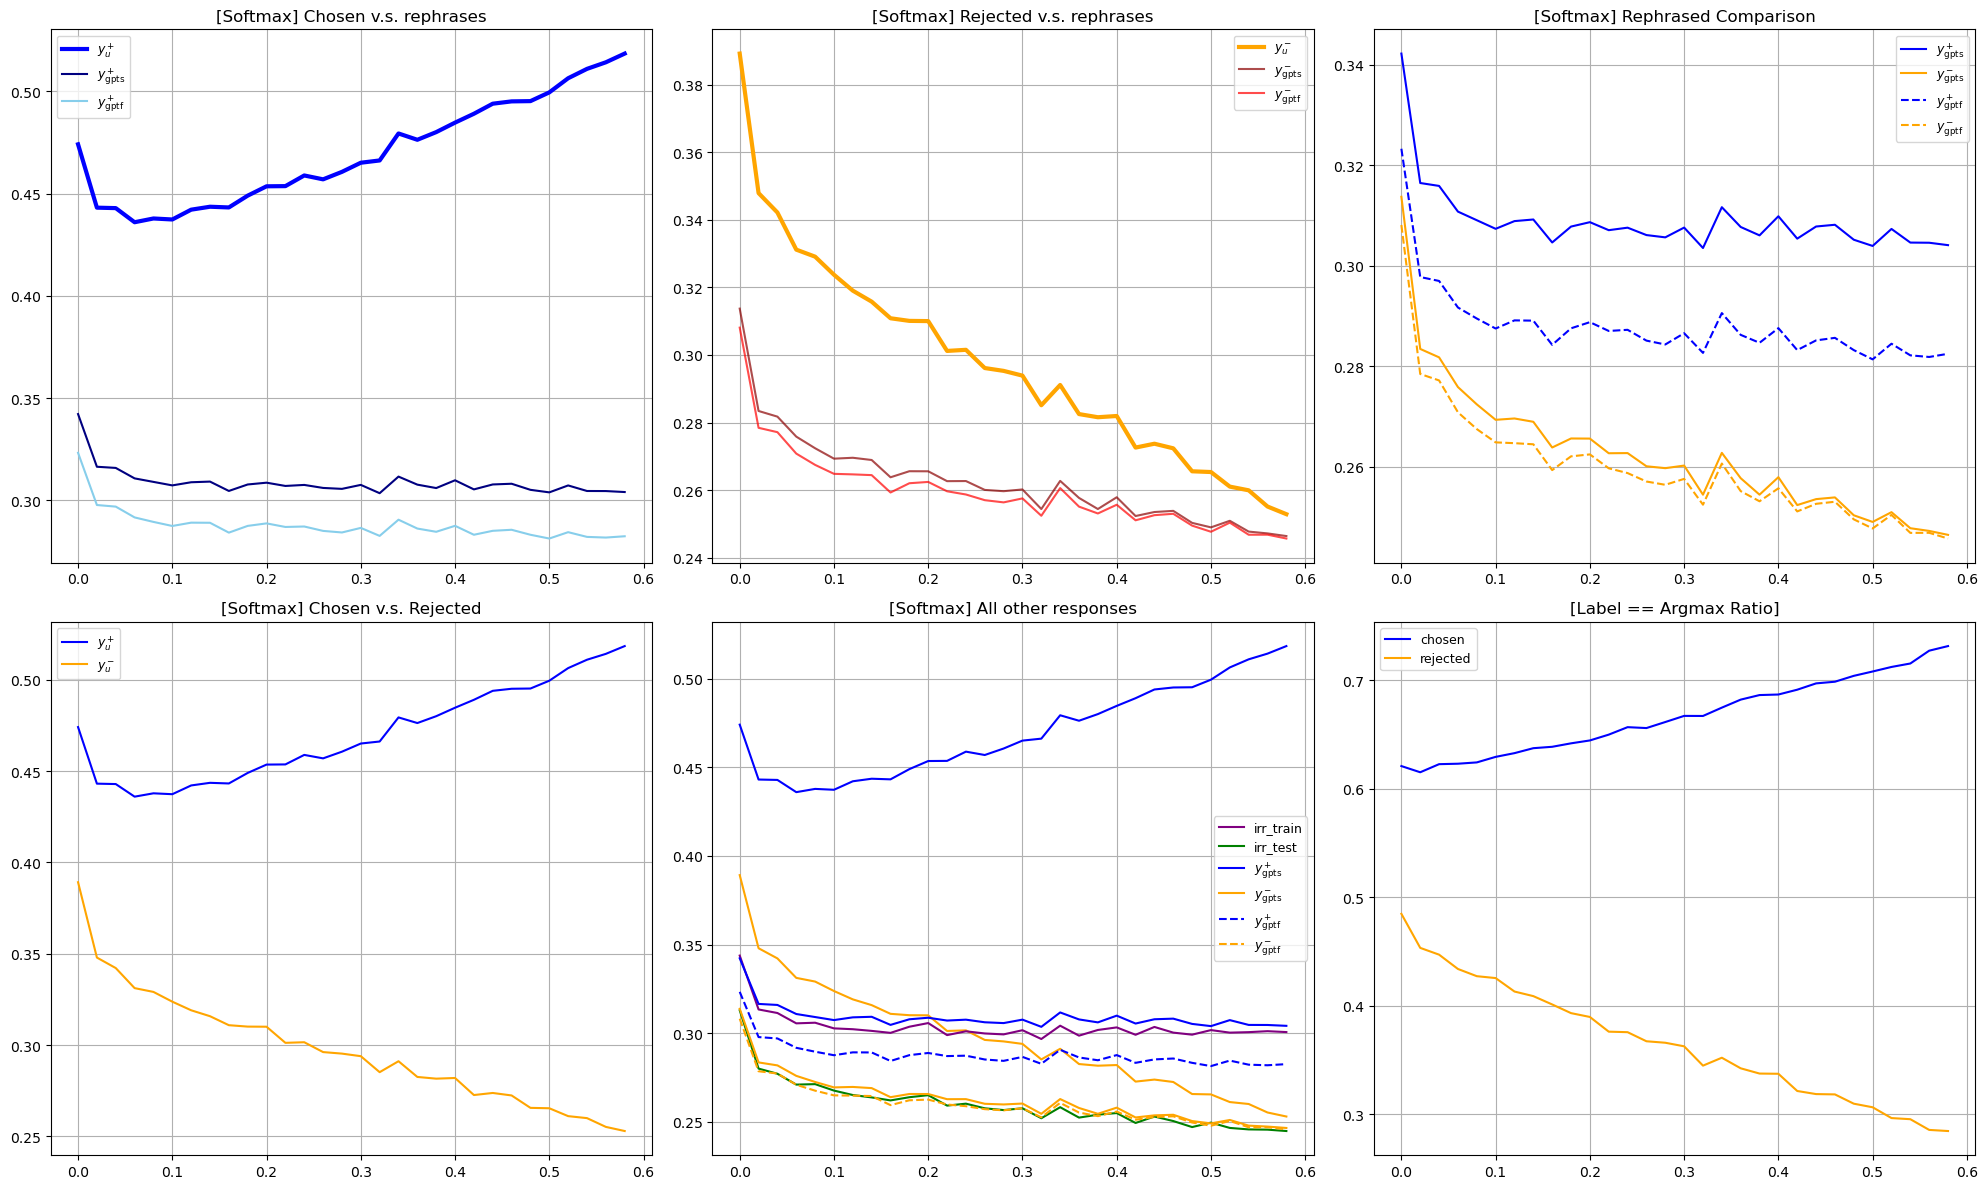

In [17]:
MODEL="masked_dpo_hh_pythia410m_ep6"
plot_softmax_dpo(PATH, MODEL)

### 12-1-RESULTS

#### Sparse DPO Qwen18 ultrafb

#### Sparse DPO Pythia410m ultrafb

#### Masked DPO Qwen18 ultrafb

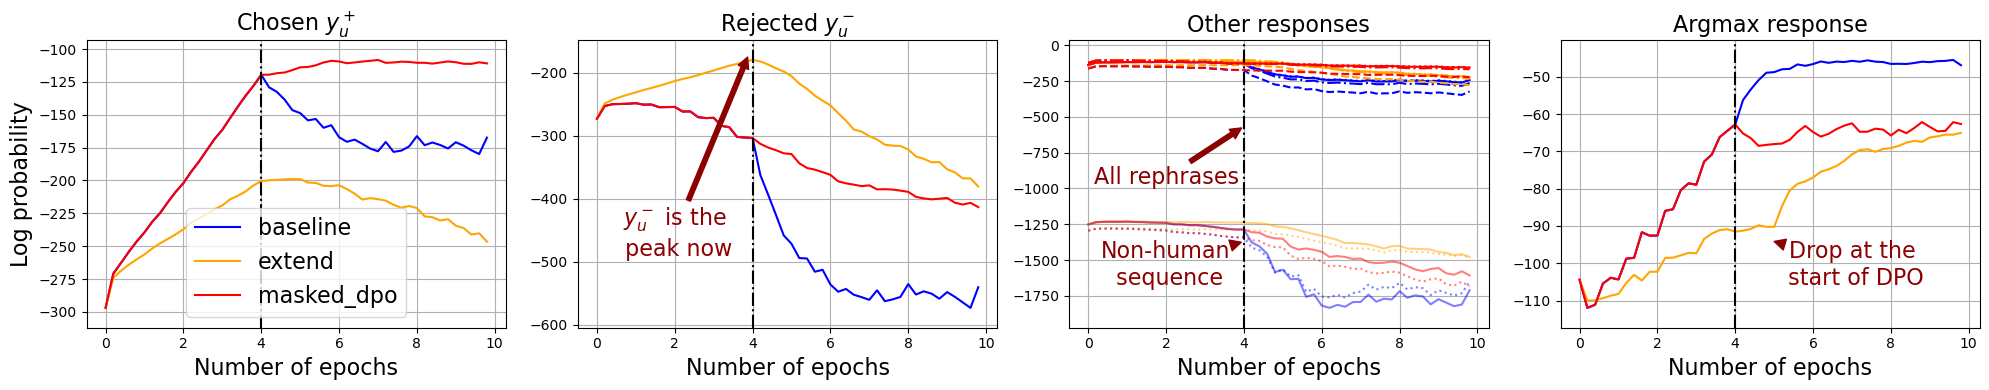

In [10]:
#   Figures
MODEL_SEQ = [("sft_qwen18_ultrafb_ep8", "dpo_base_qwen18_ultrafb_ep6"),
             ("extend_sft_qwen18_ultrafb_ep4", "dpo_extend_qwen18_ultrafb_ep6"),
             ("sft_qwen18_ultrafb_ep8", "dpo_masked_qwen18_ultrafb_ep6")
             ]
LEGENDS = ['baseline', 'extend', 'masked_dpo']
plot_dpo_graph(PATH, MODEL_SEQ, LEGENDS, COLORS, OBS_NUM, SMTH)

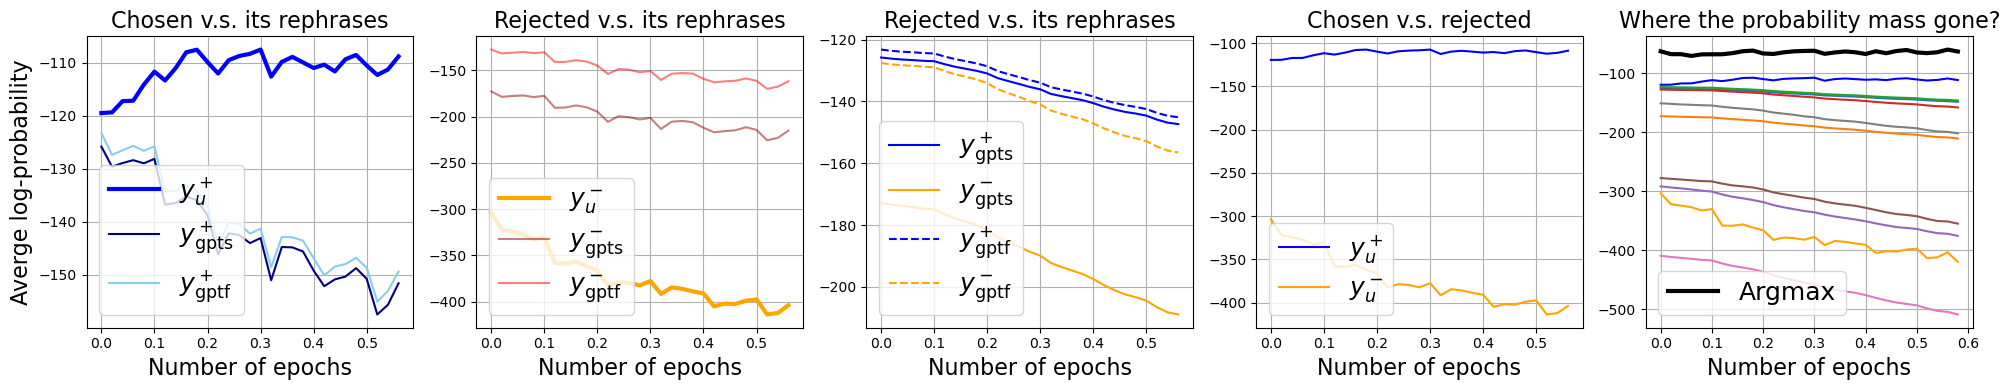

In [25]:
MODEL = "dpo_masked_qwen18_ultrafb_ep6"
plot_dpo_log_details(PATH,MODEL)

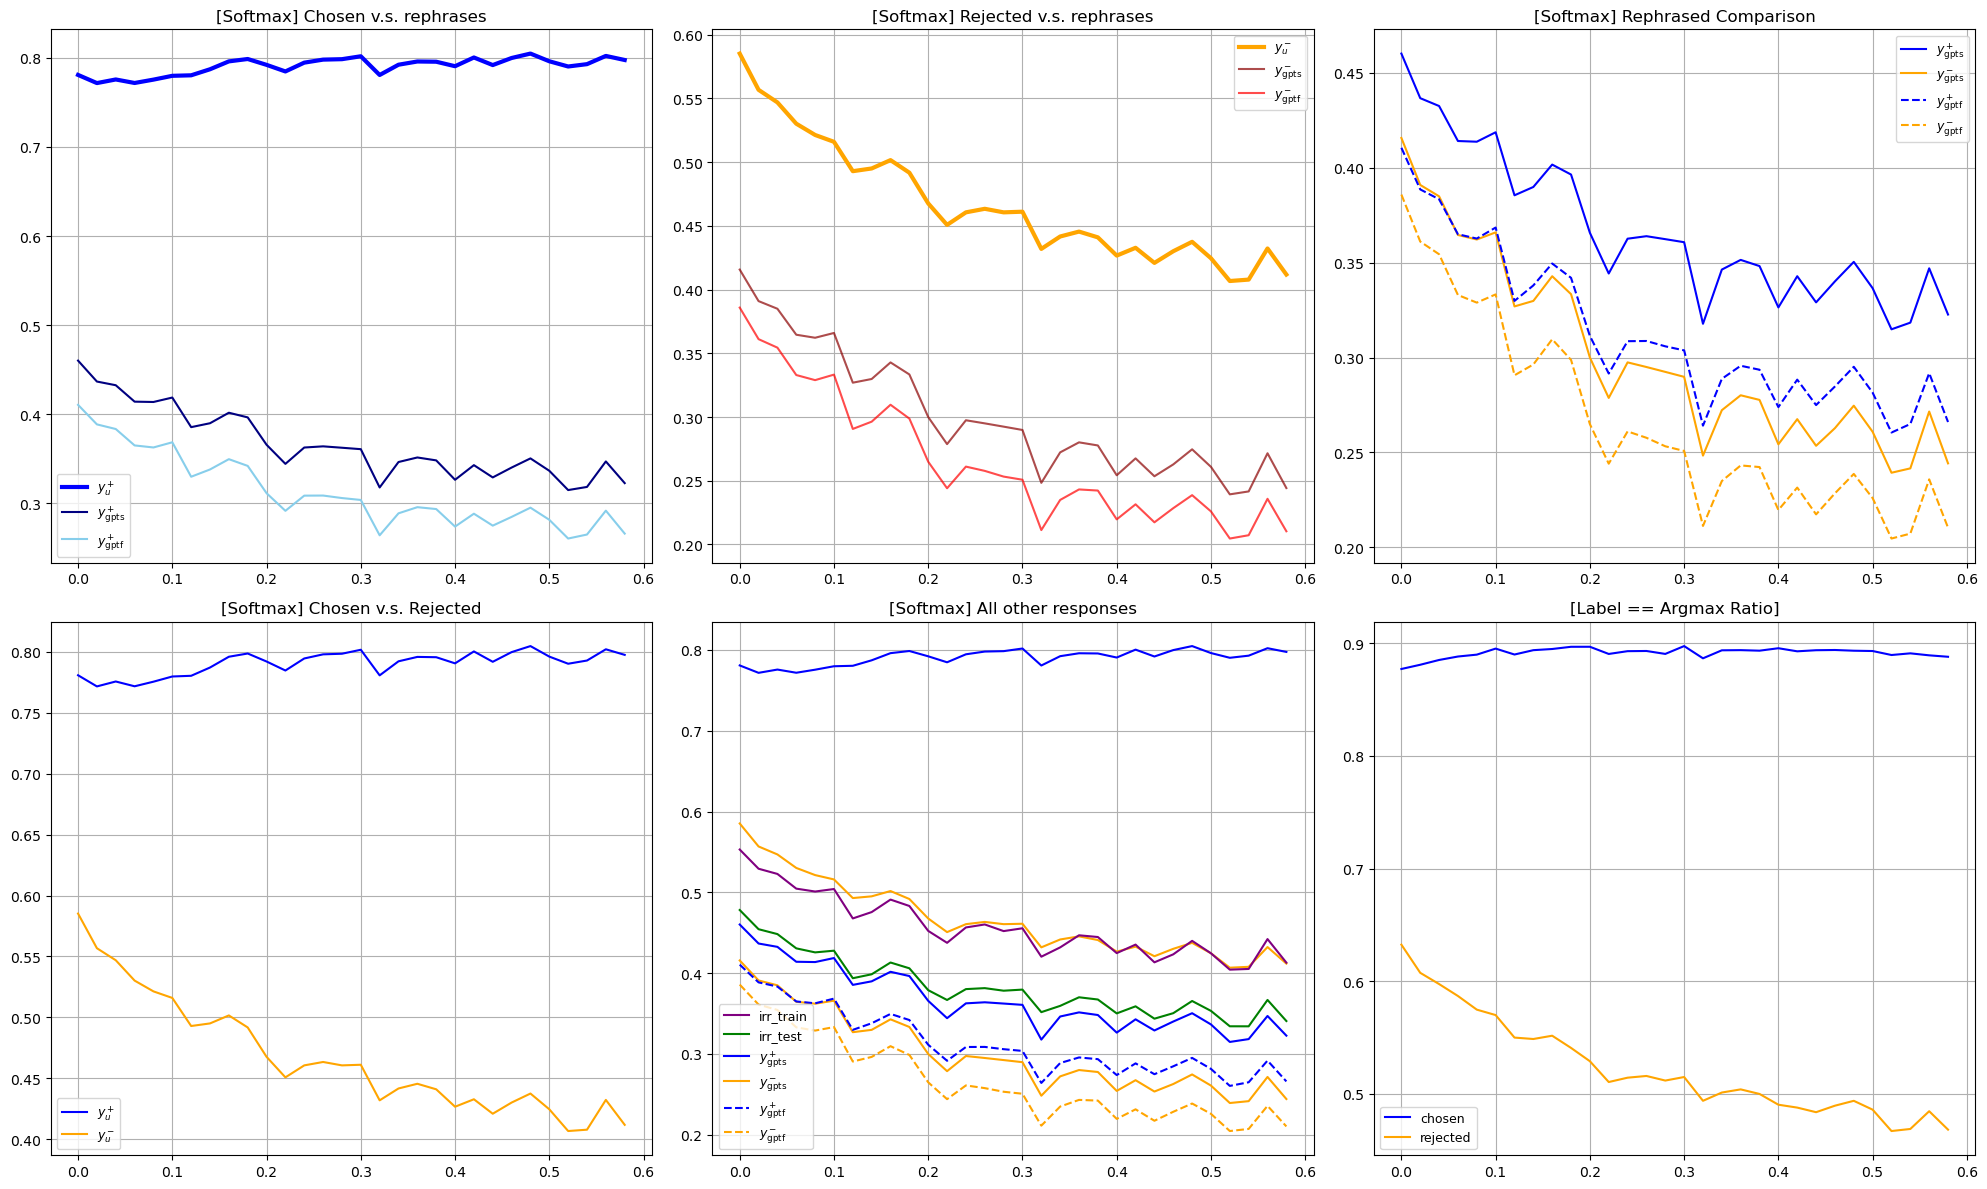

In [30]:
MODEL="dpo_masked_qwen18_ultrafb_ep6"
plot_softmax_dpo(PATH, MODEL)

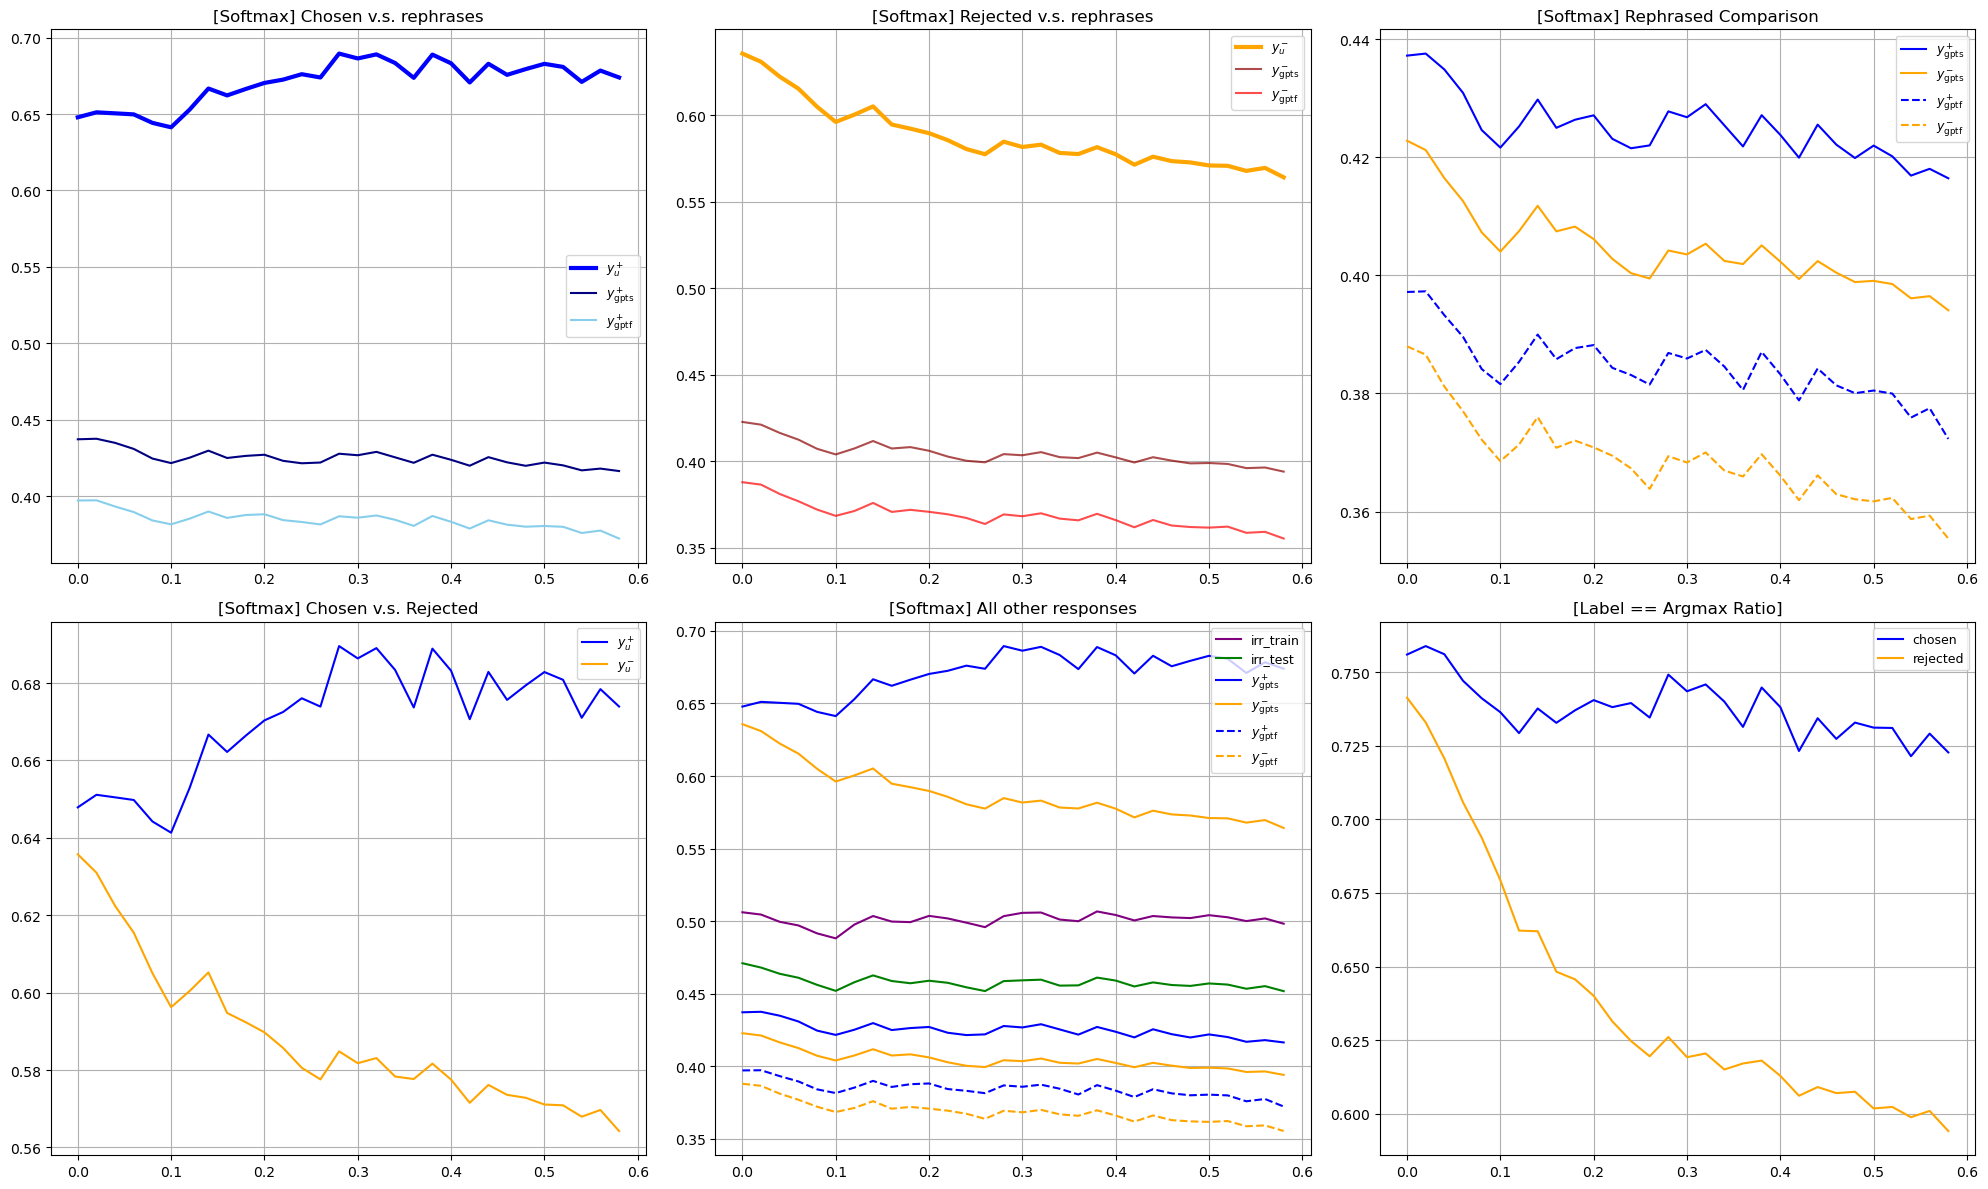

In [12]:
MODEL="dpo_extend_qwen18_ultrafb_ep6"
plot_softmax_dpo(PATH, MODEL)

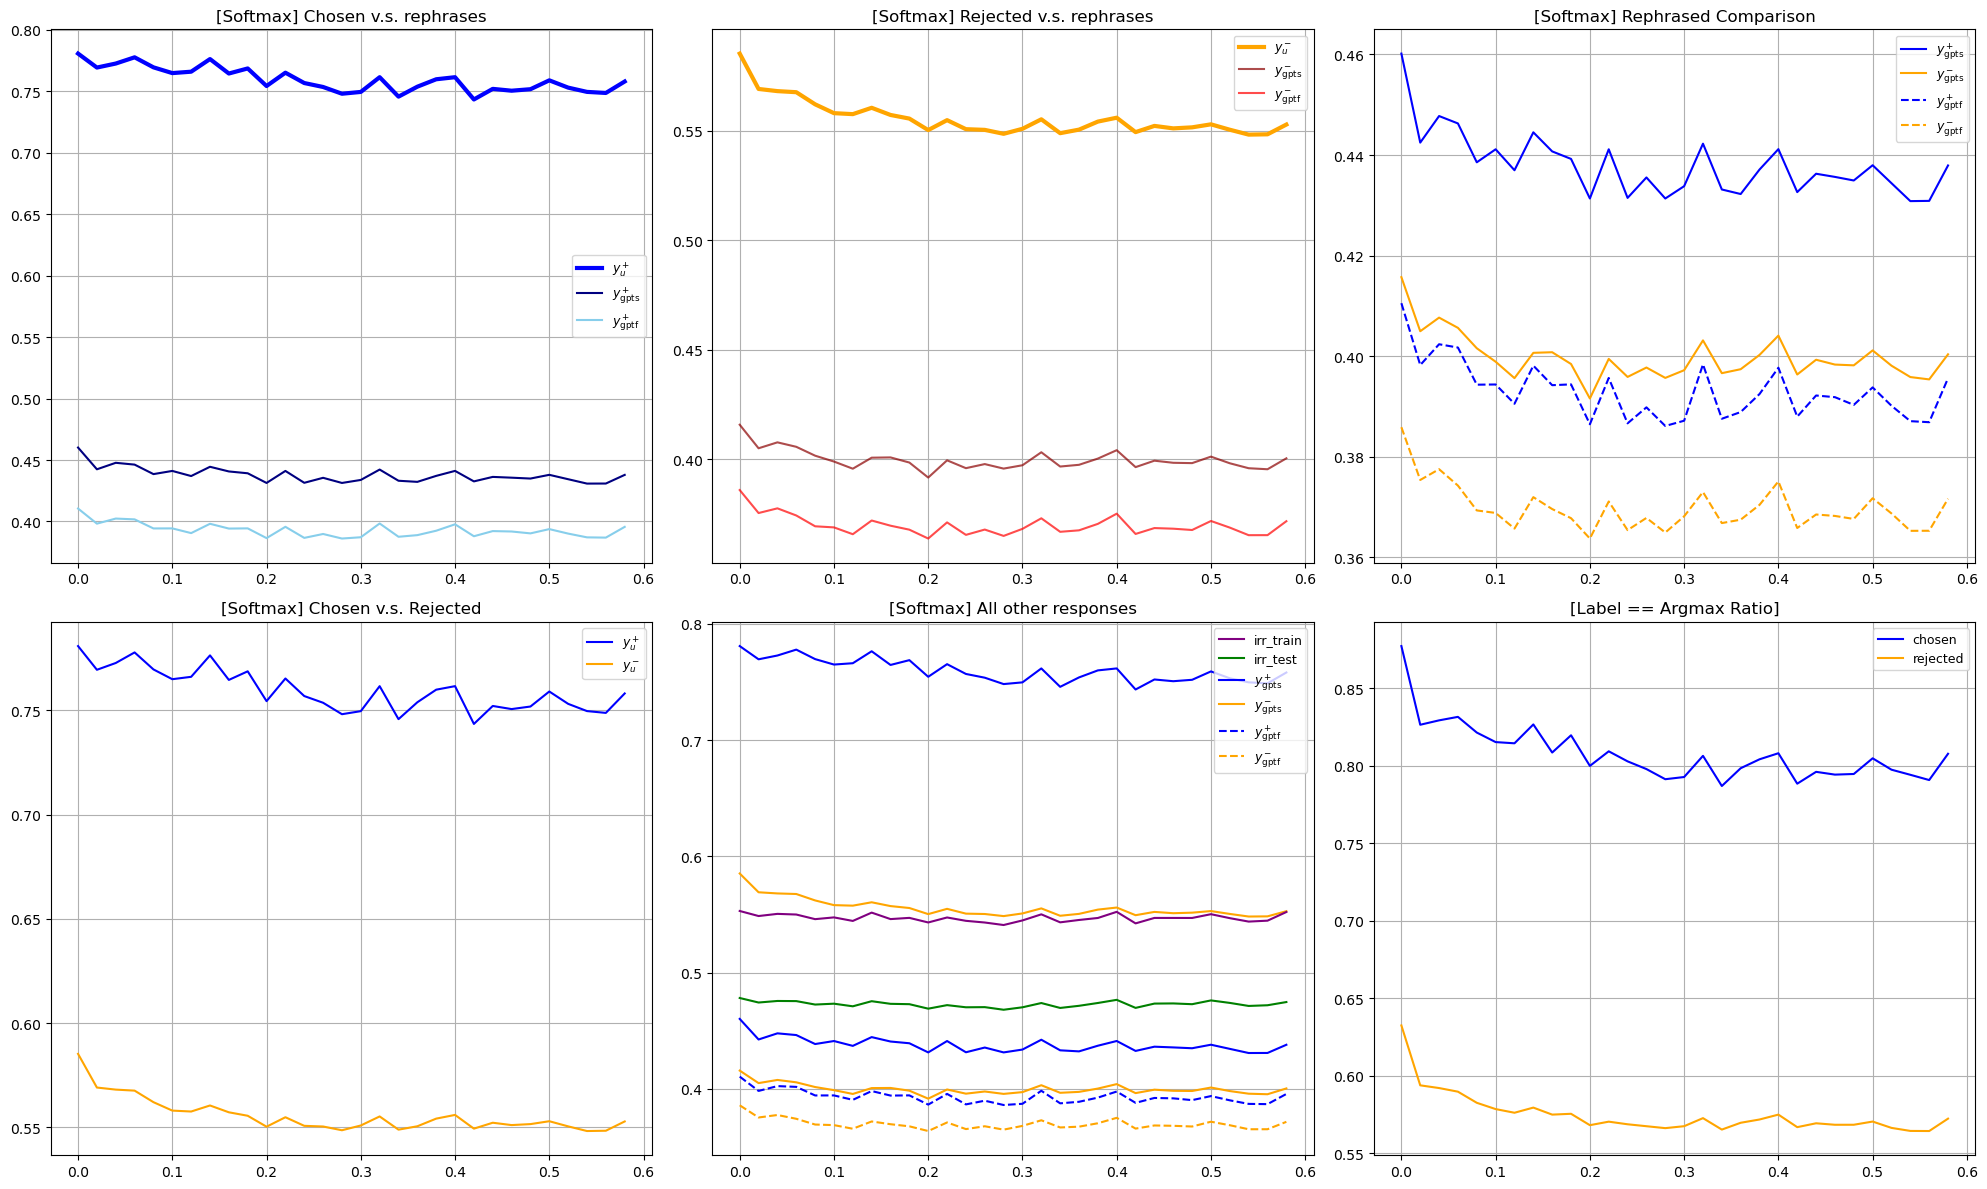

In [13]:
MODEL="dpo_base_qwen18_ultrafb_ep6"
plot_softmax_dpo(PATH, MODEL)

#### Masked DPO Pythia410m ultrafb

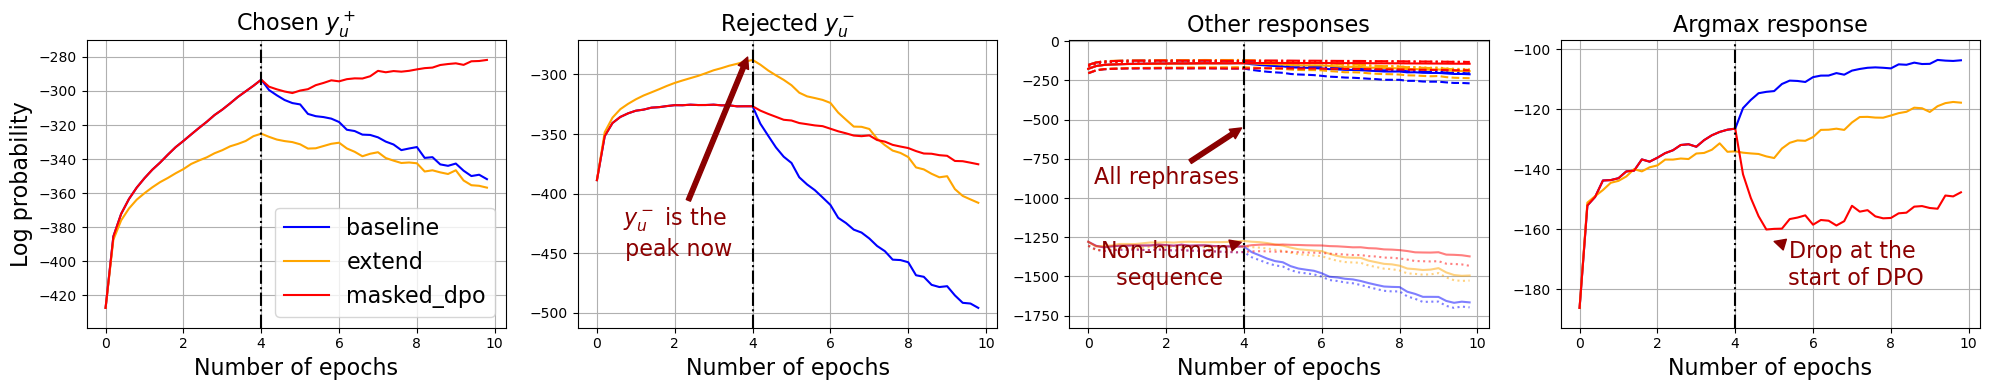

In [24]:
#   Figures
MODEL_SEQ = [("sft_pythia410m_ultrafb_ep8", "dpo_base_pythia410m_ultrafb_ep6"),
             ("extend_sft_pythia410m_ultrafb_ep4", "dpo_extend_pythia410m_ultrafb_ep6"),
             ("sft_pythia410m_ultrafb_ep8", "dpo_masked_pythia410m_ultrafb_ep6")
             ]
LEGENDS = ['baseline', 'extend', 'masked_dpo']
plot_dpo_graph(PATH, MODEL_SEQ, LEGENDS, COLORS, OBS_NUM, SMTH)

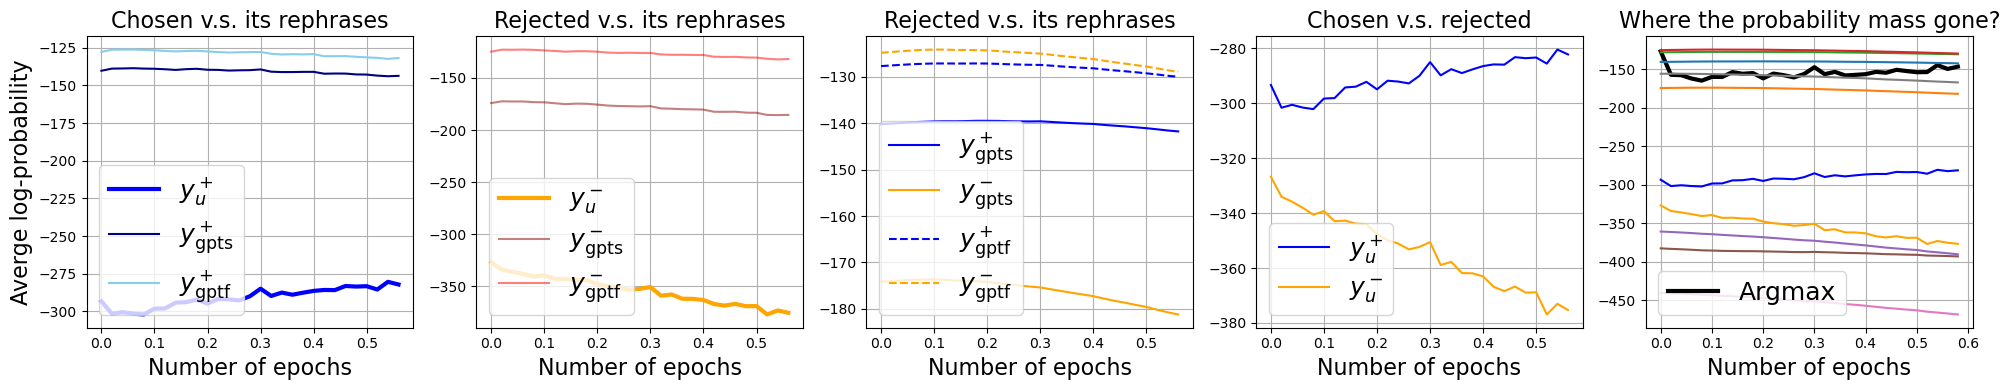

In [26]:
MODEL = "dpo_masked_pythia410m_ultrafb_ep6"
plot_dpo_log_details(PATH,MODEL)

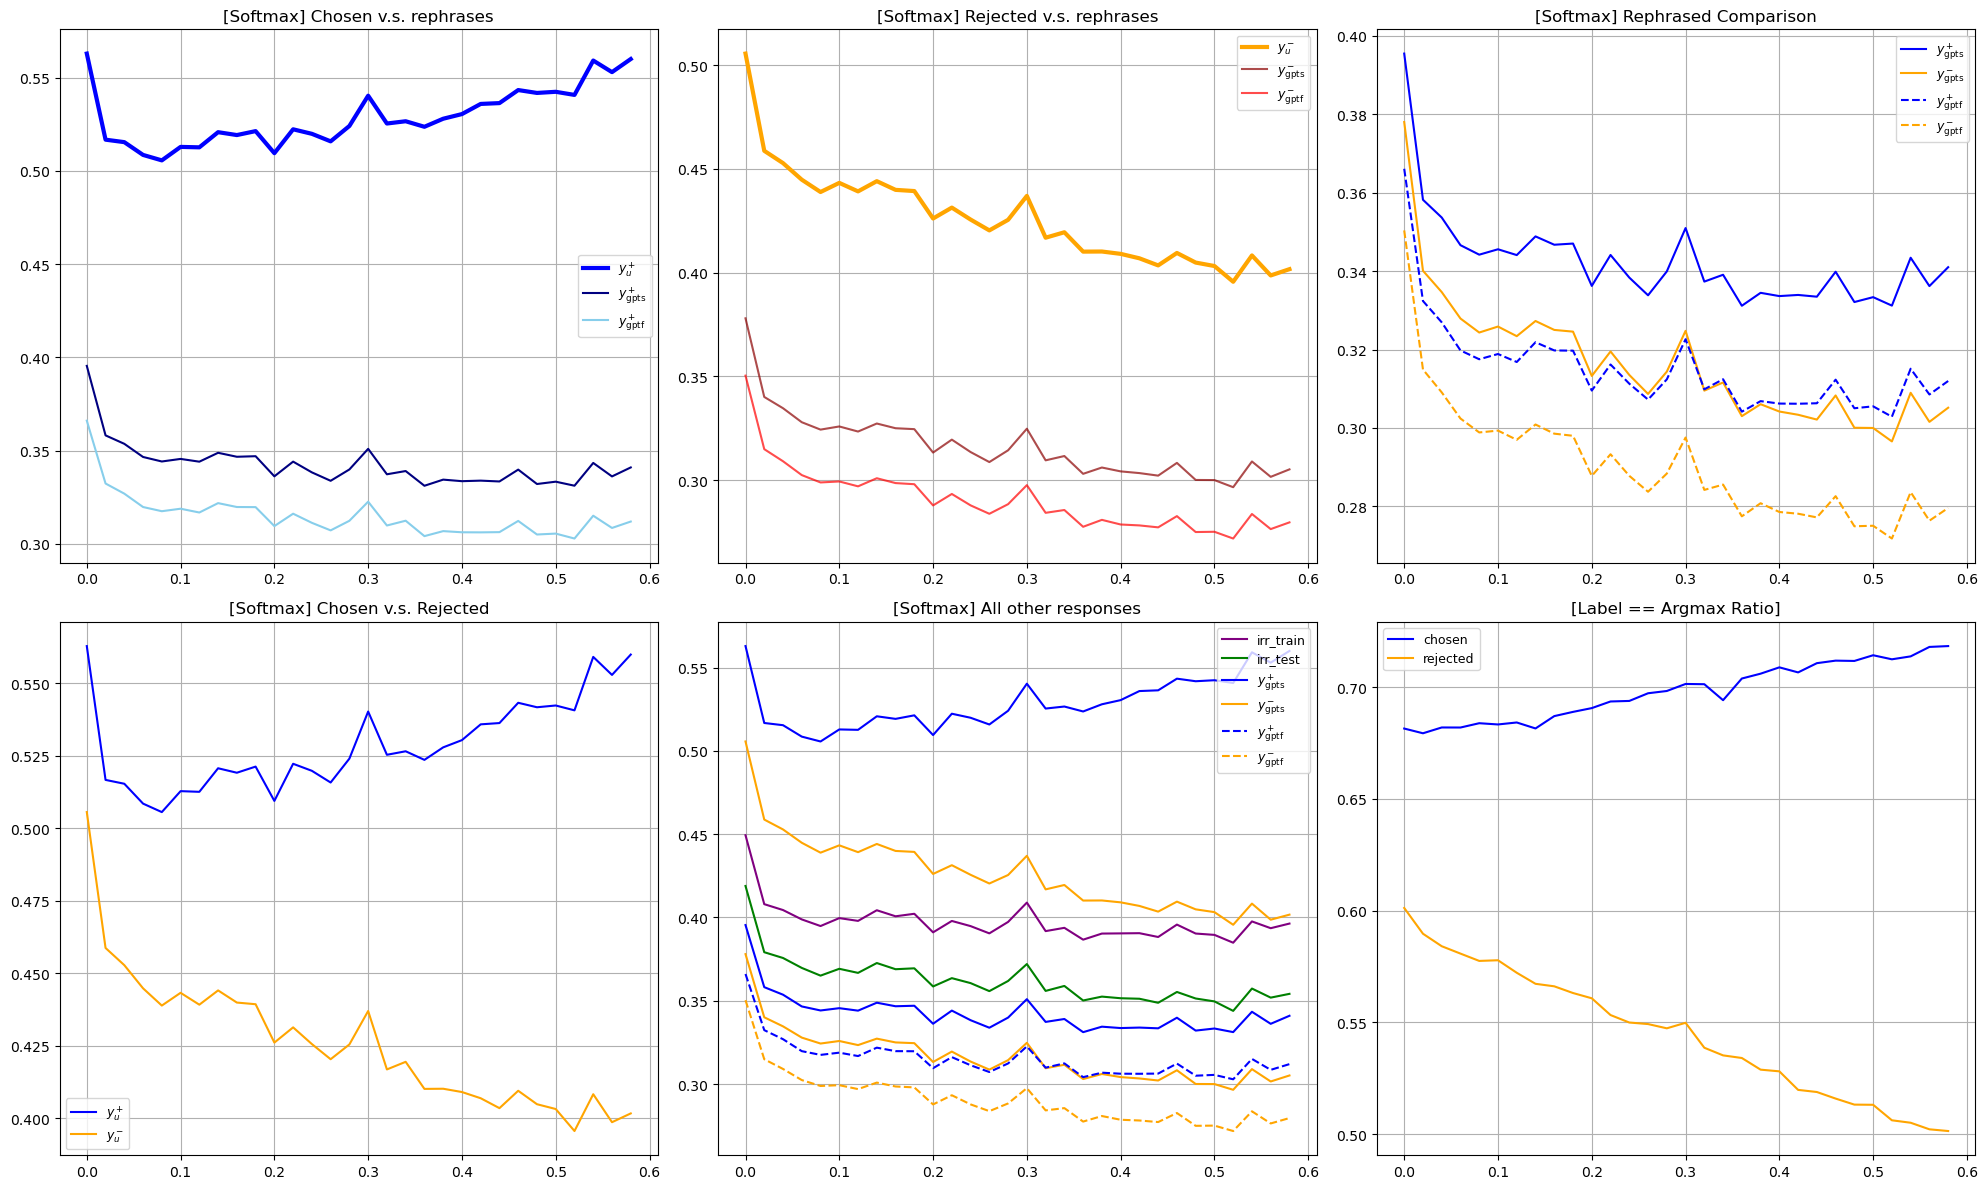

In [31]:
MODEL="dpo_masked_pythia410m_ultrafb_ep6"
plot_softmax_dpo(PATH, MODEL)